In [1]:
import sys
import os

# Navigate from notebooks/ up to src/ and add to path
sys.path.append(os.path.abspath("../.."))  # points to src/

from utils.eda_utils import pd, np, plt, sns, msno, stats

In [2]:
from utils.eda_utils import pd, np, plt, sns, msno, stats
sys.modules


{'sys': <module 'sys' (built-in)>,
 'builtins': <module 'builtins' (built-in)>,
 '_frozen_importlib': <module '_frozen_importlib' (frozen)>,
 '_imp': <module '_imp' (built-in)>,
 '_thread': <module '_thread' (built-in)>,
 '_warnings': <module '_warnings' (built-in)>,
 '_weakref': <module '_weakref' (built-in)>,
 '_io': <module '_io' (built-in)>,
 'marshal': <module 'marshal' (built-in)>,
 'posix': <module 'posix' (built-in)>,
 '_frozen_importlib_external': <module '_frozen_importlib_external' (frozen)>,
 'time': <module 'time' (built-in)>,
 'zipimport': <module 'zipimport' (frozen)>,
 '_codecs': <module '_codecs' (built-in)>,
 'codecs': <module 'codecs' (frozen)>,
 'encodings.aliases': <module 'encodings.aliases' from '/usr/lib/python3.12/encodings/aliases.py'>,
 'encodings': <module 'encodings' from '/usr/lib/python3.12/encodings/__init__.py'>,
 'encodings.utf_8': <module 'encodings.utf_8' from '/usr/lib/python3.12/encodings/utf_8.py'>,
 '_signal': <module '_signal' (built-in)>,
 '_ab

In [3]:
# Cell 3: Load the housing dataset
df = pd.read_csv('../data/raw/house-prices-advanced-regression-techniques/train.csv')

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Shape: {df.shape}")

DATASET LOADED SUCCESSFULLY
Shape: (1460, 81)


In [4]:
# Cell 4: Dataset information
print("DATASET INFORMATION")
df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18 

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "MissingCount": missing,
    "MissingPercent": (missing / len(df)) * 100
})

missing_df


,MissingCount,MissingPercent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [6]:
df['HasPool'] = df['PoolQC'].notnull().astype(int)


In [7]:
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
df = df.drop(columns=cols_to_drop)


In [8]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("=" * 60)
for x in num_cols:
    print(x)
print("=" * 60)
for x in cat_cols:
    print(x)


Id
MSSubClass
LotFrontage
LotArea
OverallQual
OverallCond
YearBuilt
YearRemodAdd
MasVnrArea
BsmtFinSF1
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
TotRmsAbvGrd
Fireplaces
GarageYrBlt
GarageCars
GarageArea
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
MiscVal
MoSold
YrSold
SalePrice
HasPool
MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


/tmp/ipykernel_68886/860766834.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [9]:
garage_cols = ['GarageType','GarageFinish','GarageQual','GarageCond']
df[garage_cols] = df[garage_cols].fillna('None')


In [10]:
# Sanity check: inspect rows with no garage
df[df['GarageType'] == 'None'][['GarageYrBlt', 'GarageArea', 'GarageCars']].head()

# Replace GarageYrBlt with 0 where there is no garage
df.loc[df['GarageType'] == 'None', 'GarageYrBlt'] = 0

# Optional verification
print("Remaining missing GarageYrBlt:", df['GarageYrBlt'].isnull().sum())



Remaining missing GarageYrBlt: 0


<Axes: >

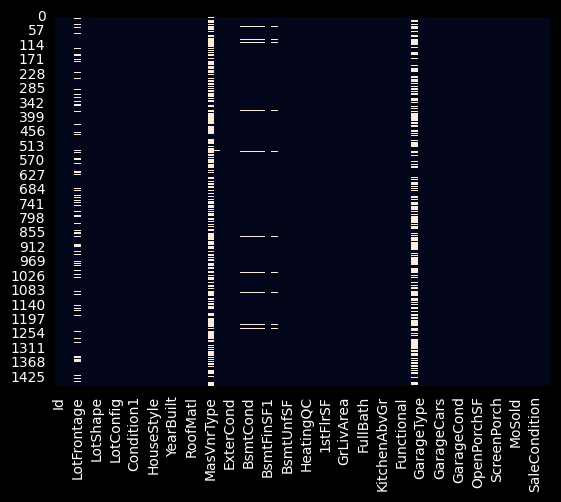

In [11]:
sns.heatmap(df.isnull(),cbar=False)


In [12]:
print(df.shape)

(1460, 78)


In [13]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtFinType1     2.534247
BsmtCond         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [14]:
df[['MasVnrType','MasVnrArea']].isnull().sum()

df[df['MasVnrType'].isnull()][['MasVnrType','MasVnrArea']].head()

df[df['MasVnrArea'].isnull()][['MasVnrType','MasVnrArea']].head()

df[df['MasVnrArea'] == 0]['MasVnrType'].value_counts(dropna=False)


MasVnrType
NaN        859
BrkFace      1
Stone        1
Name: count, dtype: int64

In [15]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)


In [16]:
df.to_csv("housing_clean_step1.csv", index=False)


In [17]:
site_cols = [col for col in df.columns if 'Bsmt' in col]
print(site_cols)

['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']


In [18]:
df[df['BsmtQual'].isnull()][
    ['BsmtFullBath','BsmtHalfBath']
].describe()


,BsmtFullBath,BsmtHalfBath
count,37.0,37.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [19]:
bsmt_cat_cols = [
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2'
]

df[bsmt_cat_cols] = df[bsmt_cat_cols].fillna('None')


In [20]:
df.isnull().sum().sort_values(ascending=False)


FireplaceQu      690
LotFrontage      259
Electrical         1
MSZoning           0
MSSubClass         0
                ... 
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
HasPool            0
Length: 78, dtype: int64

In [21]:
df[df['FireplaceQu'].isnull()]['Fireplaces'].describe()


count    690.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Fireplaces, dtype: float64

In [22]:
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')


In [23]:
print(df.columns.tolist())


['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSol

In [24]:
# Fill missing LotFrontage using median per Neighborhood
df['LotFrontage'] = (
    df.groupby('Neighborhood')['LotFrontage']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback in case an entire neighborhood had missing values
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())


In [25]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])


In [26]:
df.isnull().sum().sort_values(ascending=False)


Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
HasPool          0
Length: 78, dtype: int64

In [27]:
df.to_csv("final.csv", index=False)


In [32]:
print("X_train exists:", "X_train" in globals())
print(df.columns.tolist())


X_train exists: False
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolAr

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=[np.number]).columns
    categorical_features = X.select_dtypes(exclude=[np.number]).columns

    numeric_pipeline = Pipeline(steps=[
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="first",
            sparse_output=False
        ))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    return preprocessor


In [37]:
preprocessor = build_preprocessor(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)


/home/anshulgarg/Documents/ObsidianVault/Hestabit/Week6/day-2/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [13, 28] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
